# Logistic Regression Models

### `imports` and `data`

In [1]:
import pandas as pd
import numpy as np
import sklearn as sk
import matplotlib.pyplot as plt
import statsmodels.api as sm

datasets = {
    "All Features": ("../data/X_train.csv", "../data/X_test.csv"),
    "Independent Clusters": ("../data/X_train_cluster_independent.csv", "../data/X_test_cluster_independent.csv"),
    "Agglomerated Clusters": ("../data/X_train_cluster_agglom.csv", "../data/X_test_cluster_agglom.csv")
}

y_train = pd.read_csv("../data/y_train.csv")
y_test = pd.read_csv("../data/y_test.csv")

### With all data imported, we can create all 3 models in one shot using a for loop, and then store them in `results`

Optimization terminated successfully.
         Current function value: 0.504465
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:            felt_rested   No. Observations:                80000
Model:                          Logit   Df Residuals:                    79937
Method:                           MLE   Df Model:                           62
Date:                Thu, 30 Apr 2026   Pseudo R-squ.:                  0.2453
Time:                        14:10:36   Log-Likelihood:                -40357.
converged:                       True   LL-Null:                       -53475.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                         coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
const                                 -0.7814      0.010    

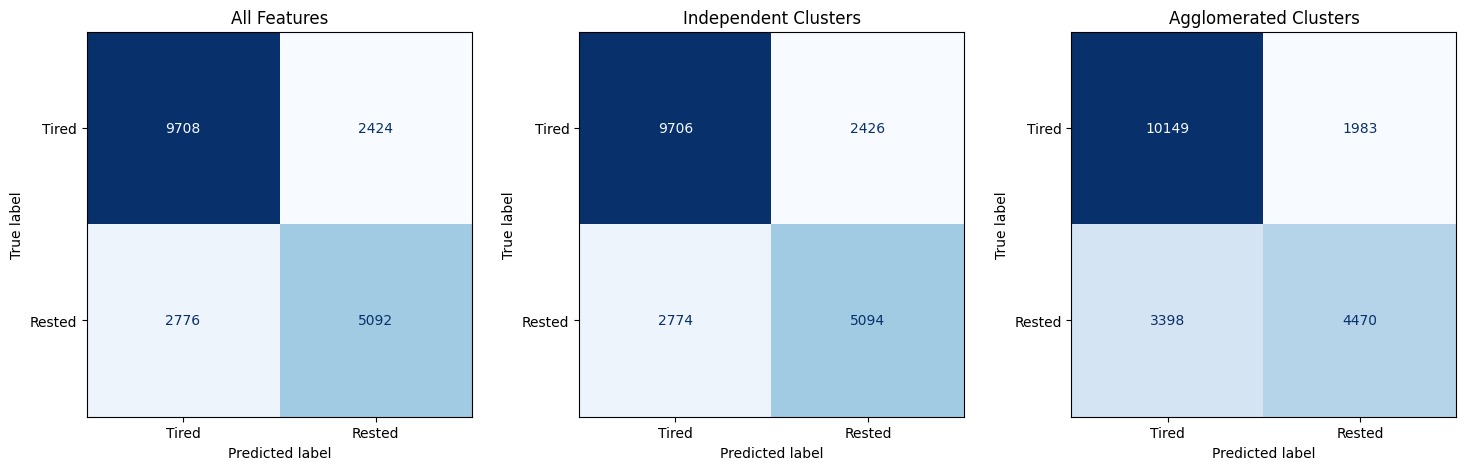

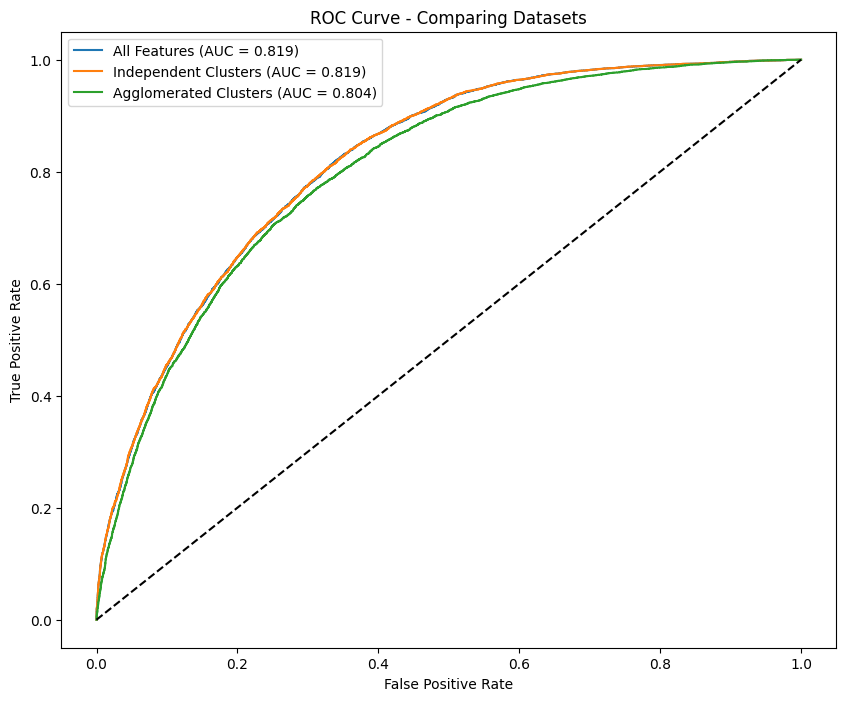

Model Comparison Summary:
                      AUC-ROC Misclassification Rate
All Features           81.91%                 26.00%
Independent Clusters   81.93%                 26.00%
Agglomerated Clusters  80.40%                 26.91%

--- Detailed Classification Report: All Features ---
              precision    recall  f1-score   support

       Tired       0.78      0.80      0.79     12132
      Rested       0.68      0.65      0.66      7868

    accuracy                           0.74     20000
   macro avg       0.73      0.72      0.73     20000
weighted avg       0.74      0.74      0.74     20000


--- Detailed Classification Report: Independent Clusters ---
              precision    recall  f1-score   support

       Tired       0.78      0.80      0.79     12132
      Rested       0.68      0.65      0.66      7868

    accuracy                           0.74     20000
   macro avg       0.73      0.72      0.73     20000
weighted avg       0.74      0.74      0.74    

In [2]:
results = {}

# format confusion matrix plots
fig_cm, axes_cm = plt.subplots(1, 3, figsize=(18, 5))
index_cm = 0

# format ROC graph
fig_roc = plt.figure(figsize=(10, 8))

for name, (train_data_path, test_data_path) in datasets.items():
    
    # building model
    X_train = pd.read_csv(train_data_path)
    X_test = pd.read_csv(test_data_path)

    X_train_sm = sm.add_constant(X_train)
    X_test_sm = sm.add_constant(X_test)

    model = sm.Logit(y_train, X_train_sm).fit()

    # predictions and metrics next, then storage
    y_probability = model.predict(X_test_sm)
    y_predicted = (y_probability > 0.5).astype(int)
    area_under_curve = sk.metrics.roc_auc_score(y_test, y_probability)
    accuracy = sk.metrics.accuracy_score(y_test, y_predicted)
    misclassification = 1 - accuracy

    results[name] = {
        "AUC-ROC": f"{area_under_curve:.2%}",
        "Misclassification Rate": f"{misclassification:.2%}",
        "Feature Count": X_train.shape[1],
        "Model": model
    }

    # plotting curve, summarize data
    false_positive_rate, true_positive_rate, _ = sk.metrics.roc_curve(y_test, y_probability)
    plt.plot(false_positive_rate, true_positive_rate, label=f"{name} (AUC = {area_under_curve:.3f})")

    print(model.summary())

    # confusion matrix
    confusion_matrix = sk.metrics.confusion_matrix(y_test, y_predicted)
    display_cm = sk.metrics.ConfusionMatrixDisplay(confusion_matrix=confusion_matrix, display_labels=["Tired", "Rested"])
    display_cm.plot(ax=axes_cm[index_cm], cmap='Blues', colorbar=False, values_format='d')
    axes_cm[index_cm].set_title(f"{name}")
    index_cm += 1
    

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Comparing Datasets')
plt.legend()
plt.show()

# Print Comparison Summary and Classification Reports
comparison_df = pd.DataFrame(results).T[['AUC-ROC', 'Misclassification Rate']]
print("Model Comparison Summary:")
print(comparison_df)

for name in datasets.keys():
    print(f"\n--- Detailed Classification Report: {name} ---")
    # Regenerate predictions for the report
    y_prob = results[name]["Model"].predict(sm.add_constant(pd.read_csv(datasets[name][1])))
    y_pred = (y_prob > 0.5).astype(int)
    print(sk.metrics.classification_report(y_test, y_pred, target_names=["Tired", "Rested"]))

### Here we have a interesting obervation: The all features model and independent features cluster model performed identically! This means that the junk cleaning we did when clustering was accurate. We see in agglomeration our AUC score goes down about 0.015, which is more or less expected given "the price of simplification", very good for reducing features from 60+ to 15.

---
## What does this say about the performance of each model?
### For `All Features` AND `Independent Clusters`
#### (Recall)  
- The model is able to find **80%** of people who are **actually** `tired`  
- The model is able to find **65%** of people who are **actually** `rested`  
#### (Precision)
- When the model **predicts** a person is `tired`, it is **correct 78%** of the time  
- When the model **predicts** a person is `rested`, it is **correct 68%** of the time  
#### (F1-Score)
- The model is **13% better** at predicting if a person is `tired`, compared to predicting if a person is `rested` (0.79 - 0.66)
### For `Agglomerated Clusters`  
#### (Recall)  
- The model is able to find **84%** of people who are **actually** `tired`  
- The model is able to find **57%** of people who are **actually** `rested`  
#### (Precision)
- When the model **predicts** a person is `tired`, it is **correct 75%** of the time  
- When the model **predicts** a person is `rested`, it is **correct 69%** of the time  
#### (F1-Score)
- The model is **17% better** at predicting if a person is `tired`, compared to predicting if a person is `rested` (0.79 - 0.62)
### Whats the takeaway from this?
- The `All Features` and `Independent Clusters` models perform identically
- Those models are notably better at predicting and finding people who are rested compared to `Agglomerated Clusters`
- All 3 models are about the same when it comes to finding and predicting tired people
- Notably, the `Agglomerated Clusters` are about **4%** better at finding tired people, but **3%** worse at predicting if they will be tired.

---
### Based off of our features and coeffecients, lets calculate what our model determined is the "peak" amount of sleep and room temperature

In [3]:
original_data = pd.read_csv("../data/Sleep_Health_Dataset.csv") 

def get_data_peak(feature_name, model_results, raw_data):
    b_linear = model_results.params[feature_name]
    b_squared = model_results.params[f"{feature_name}_sq"]
    
    # find peak of data in standardized units (z-score)
    z_peak = -b_linear / (2 * b_squared)
    
    # convert peak to normal units
    mean = raw_data[feature_name].mean()
    std = raw_data[feature_name].std()
    
    actual_peak = (z_peak * std) + mean
    return actual_peak

# use independent cluster model
all_features_model = results["Independent Clusters"]["Model"]

optimal_sleep = get_data_peak("sleep_duration_hrs", all_features_model, original_data)
optimal_temp = get_data_peak("room_temperature_celsius", all_features_model, original_data)

print("----- Data Peak Information -----")
print(f"Optimal Sleep Duration: {optimal_sleep:.2f} hours")
print(f"Optimal Room Temperature: {optimal_temp:.2f} celsius")

----- Data Peak Information -----
Optimal Sleep Duration: 7.28 hours
Optimal Room Temperature: 21.95 celsius


---
## What do the coeffecients tell us?
### For `Independent Cluster`:  
- `sleep_duration_hrs (+3.54)` and `sleep_duration_hrs_sq (-2.65)` tell us that as we approach little sleep to a certain amount of sleep (7.28 hours), the probability of feeling rested increases signifcantly. As we pass that peak, the probability of feeling rested decreases significantly.
- `room_temperature_celsius (+0.32)` and `room_temperature_celsius (-0.33)` demonstrate that the probability of feeling rested increases as it approaches 21.95 C and declines as it goes upward past this.
- `bmi (-0.16)` and `bmi_sq (+0.21)` has an irregular relationship (linear relationship is negative while squared is positive). As a result, bmi's penalty to feeling rested lessens at extreme values. Interesting idea
- `rem_sleep (+0.154)` has influence, but is likely overshadowed by `sleep_durations_hrs`.
- `wake_episodes_per_night (-0.3763)` has negative effect on feeling rested. Part of this could be because of how just a few wake episodes could damage `sleep_duration_hrs` or `rem_sleep`, giving pull on the data.
- `stress_score (-0.2980)` and `sleep_disorder_risk (-0.4455)` also have decent negative impact on feeling rested.
- The following attributes are **considered noise by the model**: `age (p=0.116)`, `deep_sleep_percentage (p=0.369)`, `caffeine_mg_before_bed (p=0.942)`, `screen_time_before_bed_mins (p=0.603)`, `exercise_day (p=0.912)`, `steps_that_day (p=0.838)`, `nap_duration_mins (p=0.515)`, `work_hours_that_day (p=0.700)`, `heart_rate_resting_bpm (p=0.217)`, `sleep_aid_used (p=0.311)`, `weekend_sleep_diff_hrs (p=0.315)`, `occupation_Doctor (p=0.101)`, `occupation_Lawyer (p=0.239)`, `occupation_Nurse (p=0.190)`, `occupation_Retired (p=0.604)`, `occupation_Student (p=0.992)`, `mental_health_condition_Anxiety (p=1.000)`, `mental_health_condition_Both (p=1.000)`, `mental_health_condition_Depression (p=1.000)`, `mental_health_condition_Healthy (p=1.000)`, `day_type_Weekday (p=1.000)`, `day_type_Weekend (p=1.000)`, `age_sq (p=0.117)`.
- The remaining features **have less pull and direction** (smaller coeffs) but **remain significant** in contributing to the models predictive power. This include features like `alcohol_units_before_bed (0.0219)` and `sleep_latency_mins (-0.0391)`.
### For `Agglomerated Clusters`:
- 6 of the 15 groupings are **considered noise by the model**: `SleepAid_Depression`, `Anxiety_Sleep_Ireg`, `SleepRoom_Temp`, `Physical_Activity`, `bmi_profile`, and `age_profile`.
- `Clinical_Disorder_ShiftWork (-1.0929)` is the grouping with the **largest negative effect on feeling rested**.
- `Sleep_Amt_Total (0.8882)` is the grouping with the **largest positive effect on feeling rested**.
- The following groups have a negative effect on feeling rested: `Alcohol_Morning (-0.1080)`, `Evening_Caffeine (-0.0950)`, `Stress_Corporate (-0.3683)`, `Screentime_bed_student (-0.0946)`.
- The following groups have a positive effect on feeling rested: `Retired_Naps (0.0878)`, `Rem_Healthy_Mental (0.2534)`.
- We could expect that `Rem_Healthy_Mental` is a result of those in a better state of mind being more likely to get more sleep and sleep at appropriate hours.
- `Retired_Naps` would indicate that those out of work, even if being affected by typical age-related sleeping problems, can sleep during the day to make up for worse sleep.
- `Screentime_bed_student` may be influenced by students getting less sleep as a result of staying up later, as opposed to the screen time.
- `Alcohol_Morning` is almost certainly to do with hangovers.

# **This is the code prior to refactoring. Kept for sake of reference. You may ignore everything past this point!**
---

Optimization terminated successfully.
         Current function value: 0.528497
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:            felt_rested   No. Observations:                80000
Model:                          Logit   Df Residuals:                    79985
Method:                           MLE   Df Model:                           14
Date:                Thu, 30 Apr 2026   Pseudo R-squ.:                  0.2094
Time:                        14:10:38   Log-Likelihood:                -42280.
converged:                       True   LL-Null:                       -53475.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const                          -0.6335      0.009    -71.003      0.000   

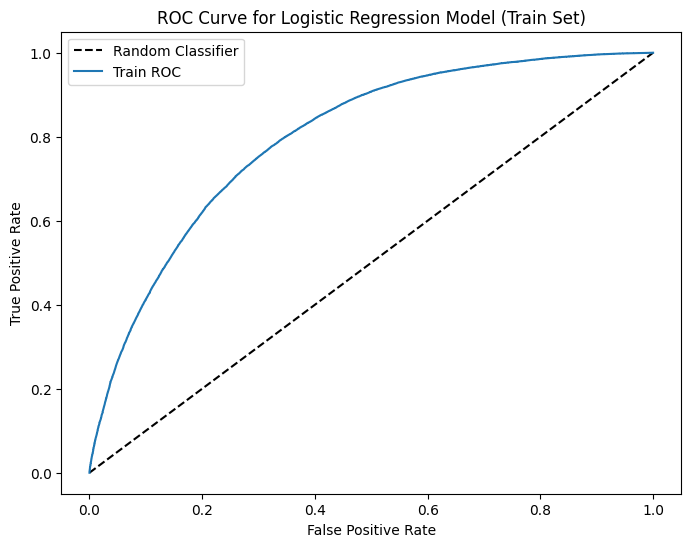

In [4]:
x_train = pd.read_csv("../data/X_train_cluster_agglom.csv")
y_train = pd.read_csv("../data/y_train.csv")
x_test = pd.read_csv("../data/X_test_cluster_agglom.csv")
y_test = pd.read_csv("../data/y_test.csv")

# Drop columns with low importance based on previous analysis (optional)

drop_cols = []

x_train = x_train.drop(columns=drop_cols)

x_test = x_test.drop(columns=drop_cols)

# Fit logistic regression model

model = sm.Logit(y_train, sm.add_constant(x_train)).fit()

#Show all coefficients and p-values

print(model.summary())

# Evaluate model performance on training and test sets

conf_matrix_train = sk.metrics.confusion_matrix(y_train, model.predict(sm.add_constant(x_train)) > 0.5)

misclassify_rate_train = (conf_matrix_train[0][1] + conf_matrix_train[1][0]) / len(y_train)

print(f"Misclassification Rate: {misclassify_rate_train:.2%}")

auc_roc_train = sk.metrics.roc_auc_score(y_train, model.predict(sm.add_constant(x_train)))
print(f"AUC-ROC: {auc_roc_train:.2%}")

conf_matrix_test = sk.metrics.confusion_matrix(y_test, model.predict(sm.add_constant(x_test)) > 0.5)

misclassify_rate_test = (conf_matrix_test[0][1] + conf_matrix_test[1][0]) / len(y_test)

print(f"Misclassification Rate: {misclassify_rate_test:.2%}")

auc_roc_test = sk.metrics.roc_auc_score(y_test, model.predict(sm.add_constant(x_test)))
print(f"AUC-ROC: {auc_roc_test:.2%}")

# Plot ROC curve for training set

plt.figure(figsize=(8, 6))
plt.plot([0, 1], [0, 1], "k--", label="Random Classifier")
fpr_train, tpr_train, _ = sk.metrics.roc_curve(y_train, model.predict(sm.add_constant(x_train)))
plt.plot(fpr_train, tpr_train, label="Train ROC")
plt.title("ROC Curve for Logistic Regression Model (Train Set)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()
